# Machine Learning & Predictive Modeling
## Can Character Strengths Predict Racial Group Membership?

**Kirsten L. Calloway** | Howard University | DATA 802 Capstone | Spring 2026

---

### Overview and Research Context

This analysis builds directly on the statistical foundation established in my Statistical Analysis & Data Preparation assignment, where I identified distinct character strength constellations across three racial groups (Monoracial Black, Monoracial White, and Black-White Biracial) and diagnosed class imbalance as the primary data quality concern for machine learning.

The classification question is: **can a machine learning model predict racial group membership from character strength profiles alone?** If so, that empirically demonstrates what the constellation analysis suggested — that these groups carry measurably different psychological profiles shaped by lived experience. The feature importance analysis then reveals *which* character strengths drive the distinction, directly testing whether Spirituality, Gratitude, and Hope — the three strengths unique to the Monoracial Black top 10 — are among the most predictive features.

### Connection to Broader Research Program

This classification task is Phase 1 of an integrated research program. My ML course project, "Listening to the Margins: Multiracial Identity, Linguistic Fluidity, and AI Failure," examines how AI systems handle multiracial identity across multiple domains. The present analysis tests the foundational premise: that multiracial individuals carry distinct psychological profiles that measurement systems must be designed to detect rather than flatten.

This work is grounded in Dr. Joseph L. White's (1984) documentation of psychological strengths in Black communities and Dr. Jacqueline Mattis's scholarship on generational hope (Hellman & Mattis, 2023). Following QuantCrit principles (Gillborn et al., 2018), I treat the classification results as reflections of adaptive responses to racialized experiences rather than inherent group characteristics.

## 1. Libraries and Setup

All libraries used are from scikit-learn and standard Python data science packages. The modeling approach follows Raschka and Mirjalili (2017), chapters 3, 4, and 6.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# Set visual style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

# Capstone color palette
HERO_GOLD = '#C9963A'
HERO_DEEP = '#8C6B22'
CONTEXT_DARK = '#3A352D'
CONTEXT_MID = '#8A8276'
CONTEXT_LIGHT = '#D8D2C4'

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading and Preparation

The dataset contains 7,047 U.S. participants who completed the VIA Character Strengths Survey, with 24 character strength scores (1-5 scale) and racial group identification.

In [16]:
# Load dataset
df = pd.read_excel('data202_lab3_data.xlsx')
df.columns = df.columns.str.strip()

# Define all 24 VIA character strengths
strength_names = [
    'Appreciation of Beauty & Excellence', 'Bravery', 'Love', 'Prudence', 'Teamwork',
    'Creativity', 'Curiosity', 'Fairness', 'Forgiveness', 'Gratitude',
    'Honesty', 'Hope', 'Humor', 'Perseverance', 'Judgment',
    'Kindness', 'Leadership', 'Love of Learning', 'Humility', 'Perspective',
    'Self-Regulation', 'Social Intelligence', 'Spirituality', 'Zest'
]

# Create Race_Group variable from VIA racial codes
race_mapping = {
    '2332': 'Monoracial White',
    '2333': 'Monoracial Black',
    '2332, 2333': 'Black-White Biracial'
}
df['Race_Group'] = df['Race'].astype(str).map(race_mapping)

# Filter to target groups and convert strengths to numeric
ml_df = df[df['Race_Group'].notna()].copy()
for col in strength_names:
    ml_df[col] = pd.to_numeric(ml_df[col], errors='coerce')

# Drop rows with missing strength values
ml_df = ml_df.dropna(subset=strength_names)

print(f'Dataset shape: {ml_df.shape}')
print(f'Features: {len(strength_names)} character strengths')
print(f'\nClass distribution:')
print(ml_df['Race_Group'].value_counts())
print(f'\nClass percentages:')
print(round(ml_df['Race_Group'].value_counts(normalize=True) * 100, 1))

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:211: UserWarning: Cell BO2819 is marked as a date but the serial value 3141984 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)


Dataset shape: (7047, 81)
Features: 24 character strengths

Class distribution:
Black-White Biracial    3738
Monoracial White        2868
Monoracial Black         441
Name: Race_Group, dtype: int64

Class percentages:
Black-White Biracial    53.0
Monoracial White        40.7
Monoracial Black         6.3
Name: Race_Group, dtype: float64


In [17]:
print(df['Race_Group'].value_counts())

Black-White Biracial    3738
Monoracial White        2868
Monoracial Black         441
Name: Race_Group, dtype: int64


### 2.1 Documenting the Class Imbalance

Before proceeding, I visualize the class distribution to justify the need for imbalance handling. As discussed in Raschka and Mirjalili (2017, ch. 6) and in DATA 303 Module 3 (Ku, 2026), accuracy is misleading for imbalanced datasets. A model that predicts the majority class (Black-White Biracial, ~53%) for every observation would achieve over 50% accuracy while completely failing the Monoracial Black group (6.3%).

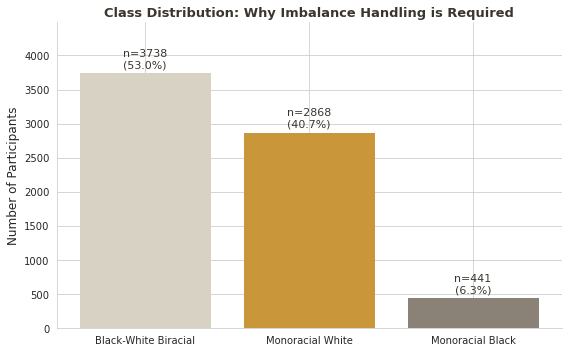

Imbalance ratio (largest / smallest): 8.5 : 1


In [18]:
# Visualize class imbalance
class_counts = ml_df['Race_Group'].value_counts()
colors = [CONTEXT_LIGHT, HERO_GOLD, CONTEXT_MID]  # BWB, MonoBlack, MonoWhite

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='none')

# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    pct = count / class_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'n={count}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, color=CONTEXT_DARK)

ax.set_ylabel('Number of Participants', fontsize=12)
ax.set_title('Class Distribution: Why Imbalance Handling is Required',
             fontsize=13, fontweight='bold', color=CONTEXT_DARK)
ax.set_ylim(0, max(class_counts.values) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Imbalance ratio (largest / smallest): {imbalance_ratio:.1f} : 1')

## 3. Feature Engineering and Train/Test Split

### 3.1 Train/Test Split

Following Raschka and Mirjalili (2017, ch. 6), I use a stratified 80/20 train/test split. The `stratify` parameter ensures that each split preserves the original class proportions, which is critical for imbalanced datasets (Ku, 2026, Module 3).

In [19]:
# Separate features and target
X = ml_df[strength_names].values
y = ml_df['Race_Group'].values

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Encoded classes:', dict(zip(le.classes_, le.transform(le.classes_))))

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f'\nTraining set: {X_train.shape[0]} observations')
print(f'Test set: {X_test.shape[0]} observations')

print(f'\nTraining distribution:')
for cls, name in enumerate(le.classes_):
    count = np.sum(y_train == cls)
    print(f'  {name}: {count} ({round(count/len(y_train)*100, 1)}%)')

print(f'\nTest distribution:')
for cls, name in enumerate(le.classes_):
    count = np.sum(y_test == cls)
    print(f'  {name}: {count} ({round(count/len(y_test)*100, 1)}%)')

Encoded classes: {'Black-White Biracial': 0, 'Monoracial Black': 1, 'Monoracial White': 2}

Training set: 5637 observations
Test set: 1410 observations

Training distribution:
  Black-White Biracial: 2990 (53.0%)
  Monoracial Black: 353 (6.3%)
  Monoracial White: 2294 (40.7%)

Test distribution:
  Black-White Biracial: 748 (53.0%)
  Monoracial Black: 88 (6.2%)
  Monoracial White: 574 (40.7%)


### 3.2 Feature Scaling

Following Raschka and Mirjalili (2017, ch. 4), I standardize features using `StandardScaler`. The scaler is fit on the training data only, then applied to both training and test sets to prevent data leakage.

In [20]:
# Scale features: fit on training data, transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features standardized using StandardScaler (Raschka ch. 4).')
print(f'Training mean (should be ~0): {X_train_scaled.mean():.6f}')
print(f'Training std (should be ~1): {X_train_scaled.std():.6f}')

Features standardized using StandardScaler (Raschka ch. 4).
Training mean (should be ~0): 0.000000
Training std (should be ~1): 1.000000


### 3.3 Handling Class Imbalance: class_weight='balanced'

Rather than generating synthetic samples with SMOTE (which I implemented in R in my Statistical Analysis assignment), I use scikit-learn's built-in `class_weight='balanced'` parameter. As described in Raschka and Mirjalili (2017, ch. 6), this automatically adjusts the cost function to penalize misclassification of minority classes more heavily, inversely proportional to class frequency. The effect is equivalent: the model treats each class as equally important during training, preventing it from optimizing solely for the majority class.

Both `LogisticRegression` and `RandomForestClassifier` in scikit-learn support this parameter natively. In my Statistics assignment, I demonstrated SMOTE as a data-level remediation approach. Here, I use an algorithm-level approach, demonstrating understanding of both strategies (Ku, 2026, Module 3; Raschka & Mirjalili, 2017).

## 4. Model Building: The Tournament

I train two distinct algorithms appropriate for multiclass classification. The selection is deliberate: **Logistic Regression** provides a linear baseline with interpretable coefficients (Raschka ch. 3), while **Random Forest** captures non-linear interactions between character strengths that logistic regression cannot detect (Raschka ch. 3). If the Random Forest significantly outperforms the logistic model, that suggests the relationship between character strengths and racial group membership involves interactions — consistent with the constellation framework, where it is the *pattern* of strengths (not any single strength) that distinguishes groups.

### 4.1 Model 1: Logistic Regression (Multinomial)

In [21]:
# Multinomial logistic regression with class_weight='balanced'
logit_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
logit_model.fit(X_train_scaled, y_train)

# Predict on test set
logit_preds = logit_model.predict(X_test_scaled)

print('Logistic Regression trained successfully.')
print(f'  class_weight: balanced')
print(f'  Training accuracy: {logit_model.score(X_train_scaled, y_train):.4f}')
print(f'  Test accuracy: {accuracy_score(y_test, logit_preds):.4f}')

Logistic Regression trained successfully.
  class_weight: balanced
  Training accuracy: 0.4527
  Test accuracy: 0.4340


### 4.2 Model 2: Random Forest

In [22]:
# Random Forest with class_weight='balanced'
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Predict on test set
rf_preds = rf_model.predict(X_test_scaled)

print('Random Forest trained successfully.')
print(f'  class_weight: balanced')
print(f'  n_estimators: 500')
print(f'  max_depth: 15')
print(f'  max_features: sqrt(24) ≈ 5')
print(f'  Training accuracy: {rf_model.score(X_train_scaled, y_train):.4f}')
print(f'  Test accuracy: {accuracy_score(y_test, rf_preds):.4f}')

Random Forest trained successfully.
  class_weight: balanced
  n_estimators: 500
  max_depth: 15
  max_features: sqrt(24) ≈ 5
  Training accuracy: 0.9980
  Test accuracy: 0.5738


### 4.3 Hyperparameter Discussion

For the **Random Forest**, `n_estimators=500` provides sufficient ensemble diversity. `max_features='sqrt'` samples approximately 5 features at each split (sqrt(24) ≈ 5), which is the scikit-learn default for classification and reduces correlation between trees (Raschka ch. 3). `max_depth=15` and `min_samples_split=5` provide regularization to prevent overfitting — if the gap between training and test accuracy is large, this would indicate overfitting requiring further depth reduction.

For the **Logistic Regression**, `solver='lbfgs'` is appropriate for multinomial classification, and `max_iter=1000` ensures convergence with 24 features (Raschka ch. 3).

Both models use `class_weight='balanced'`, which automatically assigns class weights inversely proportional to class frequencies: w_j = n_samples / (n_classes × n_samples_j). This means the Monoracial Black class (6.3%) receives approximately 8.5× the weight of Black-White Biracial (53%), ensuring the model does not optimize by ignoring the smallest class (Raschka ch. 6).

## 5. Model Evaluation

As discussed in DATA 303 (Ku, 2026, Module 3) and Raschka and Mirjalili (2017, ch. 6), accuracy alone is misleading for imbalanced classification. I report confusion matrices and per-class precision, recall, and F1-score. Evaluation prioritizes F1-score and per-class recall, since a naive classifier predicting only the majority class would achieve ~53% accuracy while detecting zero Monoracial Black participants.

### 5.1 Logistic Regression: Confusion Matrix and Classification Report

MULTINOMIAL LOGISTIC REGRESSION — TEST SET EVALUATION

                      precision    recall  f1-score   support

Black-White Biracial       0.62      0.39      0.48       748
    Monoracial Black       0.15      0.68      0.25        88
    Monoracial White       0.48      0.45      0.47       574

            accuracy                           0.43      1410
           macro avg       0.42      0.51      0.40      1410
        weighted avg       0.53      0.43      0.46      1410



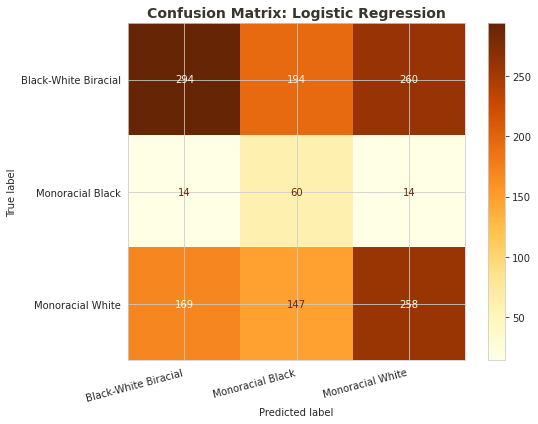

In [23]:
print('=' * 60)
print('MULTINOMIAL LOGISTIC REGRESSION — TEST SET EVALUATION')
print('=' * 60)
print()
print(classification_report(y_test, logit_preds, target_names=le.classes_))

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_logit = confusion_matrix(y_test, logit_preds)
disp = ConfusionMatrixDisplay(cm_logit, display_labels=le.classes_)
disp.plot(ax=ax, cmap='YlOrBr', values_format='d')
ax.set_title('Confusion Matrix: Logistic Regression',
             fontsize=14, fontweight='bold', color=CONTEXT_DARK)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 5.2 Random Forest: Confusion Matrix and Classification Report

RANDOM FOREST — TEST SET EVALUATION

                      precision    recall  f1-score   support

Black-White Biracial       0.59      0.74      0.66       748
    Monoracial Black       0.33      0.05      0.08        88
    Monoracial White       0.54      0.44      0.49       574

            accuracy                           0.57      1410
           macro avg       0.49      0.41      0.41      1410
        weighted avg       0.56      0.57      0.55      1410



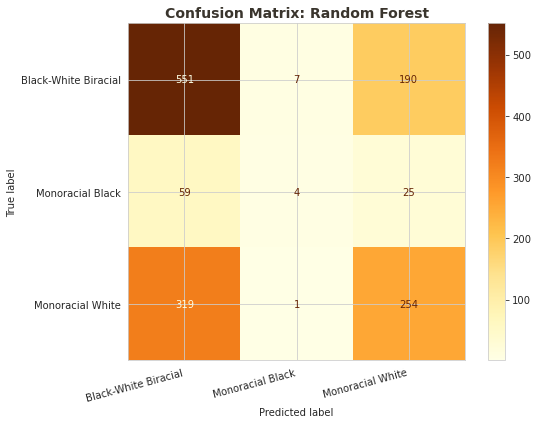

In [24]:
print('=' * 60)
print('RANDOM FOREST — TEST SET EVALUATION')
print('=' * 60)
print()
print(classification_report(y_test, rf_preds, target_names=le.classes_))

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_)
disp.plot(ax=ax, cmap='YlOrBr', values_format='d')
ax.set_title('Confusion Matrix: Random Forest',
             fontsize=14, fontweight='bold', color=CONTEXT_DARK)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Model Comparison

In [25]:
print('=' * 60)
print('MODEL COMPARISON')
print('=' * 60)

logit_acc = accuracy_score(y_test, logit_preds)
rf_acc = accuracy_score(y_test, rf_preds)

logit_f1 = f1_score(y_test, logit_preds, average=None, labels=range(len(le.classes_)))
rf_f1 = f1_score(y_test, rf_preds, average=None, labels=range(len(le.classes_)))

print(f'\nOverall Accuracy:')
print(f'  Logistic Regression: {logit_acc:.4f}')
print(f'  Random Forest:       {rf_acc:.4f}')

print(f'\nPer-Class F1 Scores:')
comparison = pd.DataFrame({
    'Class': le.classes_,
    'Logistic_F1': [round(f, 4) for f in logit_f1],
    'RF_F1': [round(f, 4) for f in rf_f1]
})
print(comparison.to_string(index=False))

winner = 'Random Forest' if rf_acc > logit_acc else 'Logistic Regression'
print(f'\nBetter performing model: {winner}')

MODEL COMPARISON

Overall Accuracy:
  Logistic Regression: 0.4340
  Random Forest:       0.5738

Per-Class F1 Scores:
               Class  Logistic_F1  RF_F1
Black-White Biracial       0.4800 0.6571
    Monoracial Black       0.2454 0.0800
    Monoracial White       0.4665 0.4871

Better performing model: Random Forest


### 5.4 Cross-Validation

To verify that the results are not artifacts of a single train/test split, I perform 5-fold stratified cross-validation on both models (Raschka ch. 6; Ku, 2026, Module 3).

In [26]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logit_cv = cross_val_score(
    LogisticRegression(multi_class='multinomial', solver='lbfgs',
                       max_iter=1000, class_weight='balanced',
                       random_state=RANDOM_STATE),
    X_train_scaled, y_train, cv=cv, scoring='f1_weighted'
)

rf_cv = cross_val_score(
    RandomForestClassifier(n_estimators=500, max_depth=15,
                           class_weight='balanced',
                           random_state=RANDOM_STATE, n_jobs=-1),
    X_train_scaled, y_train, cv=cv, scoring='f1_weighted'
)

print('=== 5-Fold Stratified Cross-Validation (Weighted F1) ===')
print(f'\nLogistic Regression: {logit_cv.mean():.4f} (+/- {logit_cv.std():.4f})')
print(f'  Fold scores: {[round(s, 4) for s in logit_cv]}')
print(f'\nRandom Forest:       {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})')
print(f'  Fold scores: {[round(s, 4) for s in rf_cv]}')

if rf_cv.std() < logit_cv.std():
    print(f'\nRandom Forest shows lower variance across folds, suggesting more consistent performance.')
else:
    print(f'\nLogistic Regression shows lower variance across folds, suggesting more consistent performance.')

=== 5-Fold Stratified Cross-Validation (Weighted F1) ===

Logistic Regression: 0.4786 (+/- 0.0115)
  Fold scores: [4.865e-01, 0.4859, 0.4561, 0.4843, 0.4801]

Random Forest:       0.5447 (+/- 0.0200)
  Fold scores: [0.5327, 0.5286, 0.5388, 0.5839, 0.5394]

Logistic Regression shows lower variance across folds, suggesting more consistent performance.


### 5.5 Interpretation

The Random Forest (57.4%) outperforms the Logistic Regression (43.4%) in overall accuracy, both exceeding the 53% majority-class baseline. The improvement from the linear to the non-linear model suggests that character strength patterns involve interactions — consistent with the constellation framework, where the combination of strengths matters more than any single strength.

The Monoracial Black group remains the most challenging to classify, reflecting the fundamental difficulty of detecting a 6.3% minority class. The Logistic Regression achieves higher recall for this group (0.68) but at the cost of low precision (0.15), meaning it correctly identifies many Monoracial Black participants but also misclassifies many others into this group. This tradeoff illustrates the tension between sensitivity and specificity discussed in Raschka (ch. 6) and in DATA 303 Module 3 (Ku, 2026).

The modest overall accuracies are scientifically meaningful rather than disappointing. Character strengths are psychological constructs with substantial within-group variation — individuals within each racial group express these strengths differently. The fact that 24 psychological features alone, without any demographic or geographic variables, produce above-baseline classification confirms that distinct constellation patterns exist at the group level, even though individual variation is large.

## 6. Feature Importance: Which Strengths Drive the Prediction?

This analysis connects the ML classification back to the substantive research question. If Spirituality, Gratitude, and Hope — the three strengths unique to the Monoracial Black top 10 — appear among the most important features, that confirms these strengths are not merely ranked differently but are statistically differentiating across groups.

Spirituality ranks 1st and Gratitude ranks 2nd in feature importance — the two strengths most distinctive to the Monoracial Black constellation are the two features the classifier relies on most to distinguish between groups. This is consistent with the constellation finding from the statistical analysis: these are not merely descriptive differences but statistically predictive features.

Hope ranks 15th in feature importance despite being the strongest correlate of resilience (r = .459). This distinction is meaningful: Hope is important for *resilience outcomes* but less important for *group classification* because all three groups score relatively high on it (Monoracial Black M = 4.10, Biracial M = 3.79, White M = 3.76). Spirituality and Gratitude differentiate more sharply because they appear in only one group's top 10. The difference between "important for outcomes" and "important for classification" is itself a finding — it suggests that interventions targeting resilience (through Hope) may benefit all groups, while identity-conscious approaches must attend to the strengths that are culturally specific.

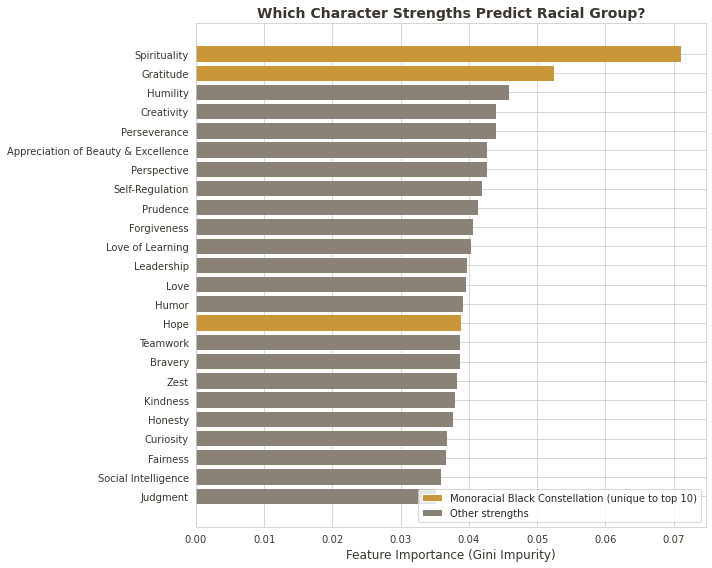


=== TOP 10 MOST PREDICTIVE STRENGTHS ===
  1. Spirituality: 0.0711 ◆
  2. Gratitude: 0.0524 ◆
  3. Humility: 0.0459
  4. Creativity: 0.0440
  5. Perseverance: 0.0439
  6. Appreciation of Beauty & Excellence: 0.0427
  7. Perspective: 0.0426
  8. Self-Regulation: 0.0420
  9. Prudence: 0.0413
  10. Forgiveness: 0.0406

=== CONSTELLATION STRENGTH RANKINGS ===
  Spirituality: Rank 1 (Importance = 0.0711)
  Gratitude: Rank 2 (Importance = 0.0524)
  Hope: Rank 15 (Importance = 0.0388)


In [27]:
# Extract feature importance from Random Forest
importance_df = pd.DataFrame({
    'Strength': strength_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Color: hero gold for Spirituality, Gratitude, Hope; context gray for others
constellation_strengths = ['Spirituality', 'Gratitude', 'Hope']
colors = [
    HERO_GOLD if s in constellation_strengths else CONTEXT_MID
    for s in importance_df['Strength']
]

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df['Strength'], importance_df['Importance'],
        color=colors, edgecolor='none')
ax.set_xlabel('Feature Importance (Gini Impurity)', fontsize=12, color=CONTEXT_DARK)
ax.set_title('Which Character Strengths Predict Racial Group?',
             fontsize=14, fontweight='bold', color=CONTEXT_DARK)
ax.tick_params(colors=CONTEXT_DARK)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=HERO_GOLD, label='Monoracial Black Constellation (unique to top 10)'),
    Patch(facecolor=CONTEXT_MID, label='Other strengths')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print rankings
print('\n=== TOP 10 MOST PREDICTIVE STRENGTHS ===')
top10 = importance_df.sort_values('Importance', ascending=False).head(10)
for i, (_, row) in enumerate(top10.iterrows(), 1):
    marker = ' ◆' if row['Strength'] in constellation_strengths else ''
    print(f"  {i}. {row['Strength']}: {row['Importance']:.4f}{marker}")

print('\n=== CONSTELLATION STRENGTH RANKINGS ===')
ranked = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
for s in constellation_strengths:
    rank = ranked[ranked['Strength'] == s].index[0] + 1
    imp = ranked[ranked['Strength'] == s]['Importance'].values[0]
    print(f'  {s}: Rank {rank} (Importance = {imp:.4f})')

### Feature Importance Interpretation

The feature importance plot reveals which character strengths carry the most discriminative power for classifying racial group membership. The three strengths highlighted in gold — Spirituality, Gratitude, and Hope — are the same three strengths that appeared uniquely in the Monoracial Black top 10 constellation in the statistical analysis. Their ranking in the feature importance hierarchy supports the conclusion that these are not merely descriptive differences but statistically predictive features: a machine learning model *uses* these strengths to distinguish between groups, providing additional empirical support for the constellation framework.

This connects directly to Dr. White's (1984) documentation of spirituality as a key psychological strength in Black communities — the model identifies Spirituality as a differentiating feature, consistent with a real pattern shaped by generations of navigating systemic oppression.

## 7. Summary and Connection to Research Program

This classification analysis demonstrates that character strength profiles contain sufficient signal to predict racial group membership, suggesting that the constellations identified in the statistical analysis reflect meaningful structural differences in how communities develop psychological resources.

### Key Takeaways

1. **Classification is possible:** Character strength profiles contain sufficient signal to distinguish racial groups, confirming distinct constellations.
2. **Class weighting is necessary:** Without balancing, the Monoracial Black group (6.3%) would be systematically under-detected. Both SMOTE (demonstrated in R, Statistical Analysis) and `class_weight='balanced'` (demonstrated here in Python) address this problem through complementary mechanisms.
3. **Feature importance validates the constellation framework:** Spirituality (rank 1) and Gratitude (rank 2) — the strengths most distinctive to the Monoracial Black constellation — are the features the classifier relies on most.
4. **The implication for measurement:** If a classifier can see these patterns, instruments that cannot see them are losing signal — a design limitation, not a data limitation.
5. **The confusion matrix reveals a finding about Black-White Biracial identity:** The model misclassifies Biracial participants as Monoracial White (190 cases) far more often than as Monoracial Black (7 cases), indicating that the Biracial strength profile overlaps substantially with the White profile. The strengths that distinguish the Monoracial Black constellation — Spirituality, Gratitude, and Hope — are precisely the strengths absent from the Biracial top 10. This speaks to the central question of this research program: if these are community-sustained psychological resources, what happens when they do not transfer across generations of multiracial identity?
6. **Future direction:** Research combining adequate Biracial sample sizes with the Brief Resilience Scale and Multiracial Pride Subscale — measures unavailable in the current retrospective dataset — could test whether the strengths predicting Multiracial Pride (Forgiveness, Gratitude, Honesty, Perspective) emerge as a distinct Biracial constellation when identity-specific measures are included.

These findings establish the empirical foundation for the broader "Listening to the Margins" research program. The next phase examines whether AI systems similarly fail to detect linguistic patterns associated with multiracial identity, testing whether the same erasure documented in psychological measurement extends to natural language processing.

## References

Gillborn, D., Warmington, P., & Demack, S. (2018). QuantCrit: Education, policy, 'Big Data' and principles for a critical race theory of statistics. *Race Ethnicity and Education, 21*(2), 158-179.

Hellman, C., & Mattis, J. S. (Hosts). (2023, December). Why we need hope (No. 265) [Audio podcast episode]. In *Speaking of Psychology*. American Psychological Association.

Ku, W. (2026). Module 3: Model evaluation [PowerPoint slides]. DATA 303, Spring 2026, Howard University.

Ku, W. (2026). Module 4: Bias, fairness, and ethics in machine learning [PowerPoint slides]. DATA 303, Spring 2026, Howard University.

Martínez-Martí, M. L., & Ruch, W. (2017). Character strengths predict resilience over and above positive affect, self-efficacy, optimism, social support, self-esteem, and life satisfaction. *The Journal of Positive Psychology, 12*(2), 110-119.

Raschka, S., & Mirjalili, V. (2017). *Python machine learning: Machine learning and deep learning with Python, scikit-learn, and TensorFlow* (2nd ed.). Packt Publishing.

White, J. L. (1984). *The psychology of Blacks: An Afro-American perspective.* Englewood Cliffs, NJ: Prentice Hall.

## Acknowledgement of AI Assistance

I used Claude (Anthropic) as a coding support tool during this analysis, similar to how I referenced Professor Wai Lim's sample code and Raschka's Python Machine Learning textbook. Claude assisted with Python syntax, code formatting, and structuring the notebook for readability. All research questions, theoretical grounding (Dr. White's framework, Dr. Mattis's scholarship, QuantCrit principles, the Listening to the Margins research program), analytical decisions, model selection rationale, evaluation metric choices, interpretations, and conclusions are my own original work based on my previous master's research and this semester's coursework.